# 03 Exploratory Data Analysis (EDA)

## 1. Objective


##  Class Distribution Analysis

### Objective

Understand how the target variable is distributed and determine whether the dataset is balanced or imbalanced.

This analysis helps identify potential modeling challenges and guides the selection of appropriate evaluation metrics and sampling techniques.

### Business Question

Is the dataset balanced, or are fraudulent transactions significantly underrepresented compared to legitimate transactions?

### Why is this analysis important?

Before training any machine learning model, it is essential to understand the distribution of the target variable.

An imbalanced dataset can bias the model toward the majority class, leading to misleading evaluation results if accuracy is used as the primary metric.

Understanding the class distribution helps in selecting suitable preprocessing techniques, sampling strategies, and evaluation metrics.

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display Settings
pd.set_option("display.max_columns", None)

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")


## 2. Import Libraries

In [2]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Display Settings
pd.set_option("display.max_columns", None)

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

## 3. Load Dataset


In [3]:
DATA_PATH = Path(r"D:\Fraud Detection\data\raw\creditcard.csv")
df = pd.read_csv(DATA_PATH)
print("Dataset loaded successfully.")

Dataset loaded successfully.


In [4]:
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,4.356170,-1.593105,2.711941,-0.689256,4.626942,-0.924459,1.107641,1.991691,0.510632,-0.682920,1.475829,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,-0.975926,-0.150189,0.915802,1.214756,-0.675143,1.164931,-0.711757,-0.025693,-1.221179,-1.545556,0.059616,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,-0.484782,0.411614,0.063119,-0.183699,-0.510602,1.329284,0.140716,0.313502,0.395652,-0.577252,0.001396,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,-0.399126,-1.933849,-0.962886,-1.042082,0.449624,1.962563,-0.608577,0.509928,1.113981,2.897849,0.127434,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0



## 4. Univariate Analysis

## Class Distribution

In [5]:
class_counts = df['Class'].value_counts()

In [6]:
class_counts = df['Class'].value_counts()
class_pcts = df['Class'].value_counts(normalize=True) * 100

print(class_counts)
print(class_pcts.round(2))

Class
0    284315
1       492
Name: count, dtype: int64
Class
0    99.83
1     0.17
Name: proportion, dtype: float64


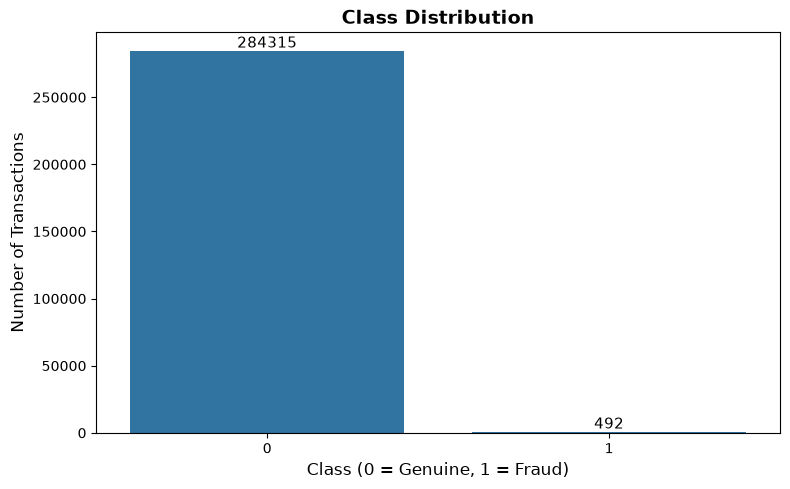

In [7]:
# Plot
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df, 
    x='Class'
)

#annotate class count
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.title('Class Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Class (0 = Genuine, 1 = Fraud)', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)

plt.tight_layout()

# Save Figure
plt.savefig(
    r"D:\Fraud Detection\reports\figures\class_distribution.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

##  Transaction Amount Analysis

### Objective

Analyze the distribution of transaction amounts to understand customer spending behavior, identify potential outliers, and determine whether transaction amount may influence fraud detection.

The findings from this analysis will also help decide whether feature scaling is required during preprocessing.

### Business Questions

1. How are transaction amounts distributed?
2. Are most transactions of low value or high value?
3. Are there any extreme transaction amounts (outliers)?
4. Is the distribution symmetric or skewed?
5. Does the Amount feature require scaling before model training?

### Why is this analysis important?

Transaction amount is one of the few features that retains its original business meaning.

Understanding its distribution helps identify customer spending patterns, detect unusually large transactions, and determine whether preprocessing techniques such as feature scaling or outlier handling are necessary.

In [8]:
amount_stats = df['Amount'].describe()
amount_stats

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

In [9]:
print("Descriptive Statistics")
print(amount_stats)

print("\nMedian Transaction Amount:")
print(df['Amount'].median())

print("\nStandard Deviation:")
print(df['Amount'].std())

print("\nVariance:")
print(df['Amount'].var())

print("\nSkewness:")
print(df['Amount'].skew())

Descriptive Statistics
count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

Median Transaction Amount:
22.0

Standard Deviation:
250.12010924018855

Variance:
62560.06904632386

Skewness:
16.977724453761006


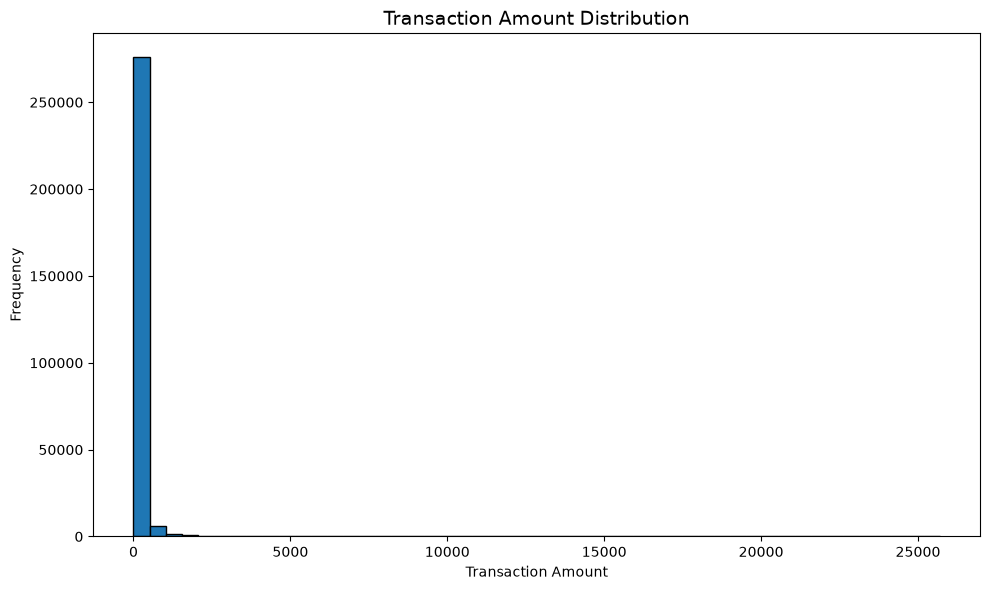

In [10]:
plt.figure(figsize=(10,6))

plt.hist(
    df['Amount'],
    bins=50,
    edgecolor = 'black'
)

plt.title('Transaction Amount Distribution', fontsize=14)
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')

plt.tight_layout()

plt.savefig(
    r"D:\Fraud Detection\reports\figures\amount_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

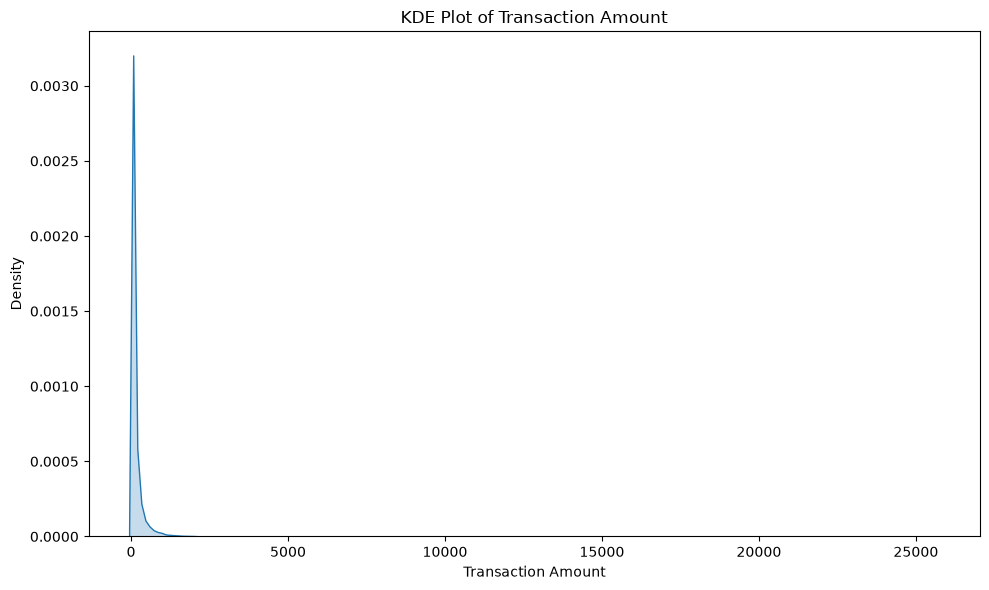

In [11]:
plt.figure(figsize=(10,6))

sns.kdeplot(
    data=df,
    x='Amount',
    fill=True
)

plt.title('KDE Plot of Transaction Amount')
plt.xlabel('Transaction Amount')

plt.tight_layout()

plt.savefig(
    r"D:\Fraud Detection\reports\figures\amount_distribution_kdeplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

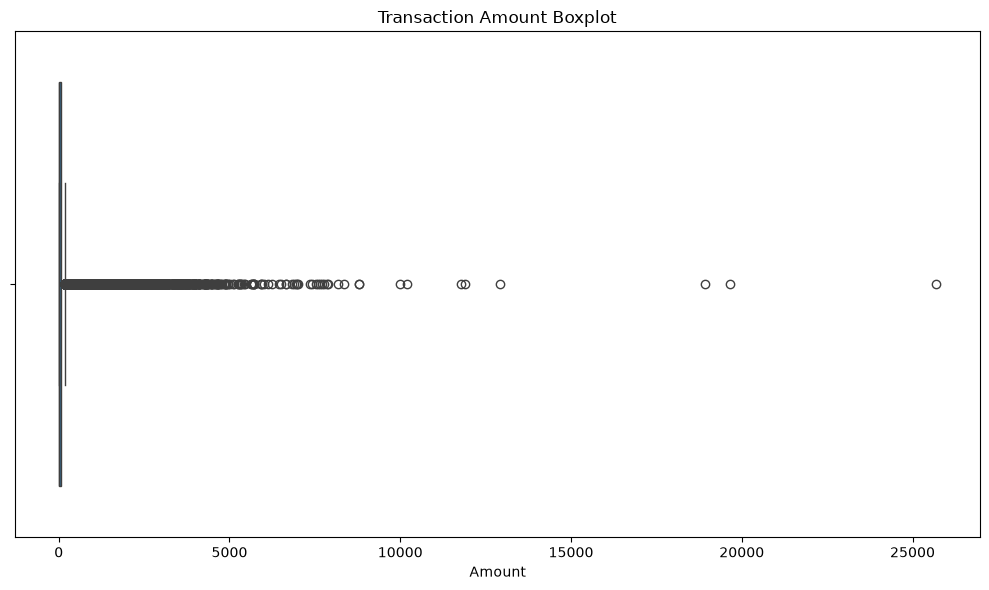

In [12]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x=df['Amount']
)

plt.title('Transaction Amount Boxplot')

plt.tight_layout()

plt.savefig(
    r"D:\Fraud Detection\reports\figures\boxPLOT_amount_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

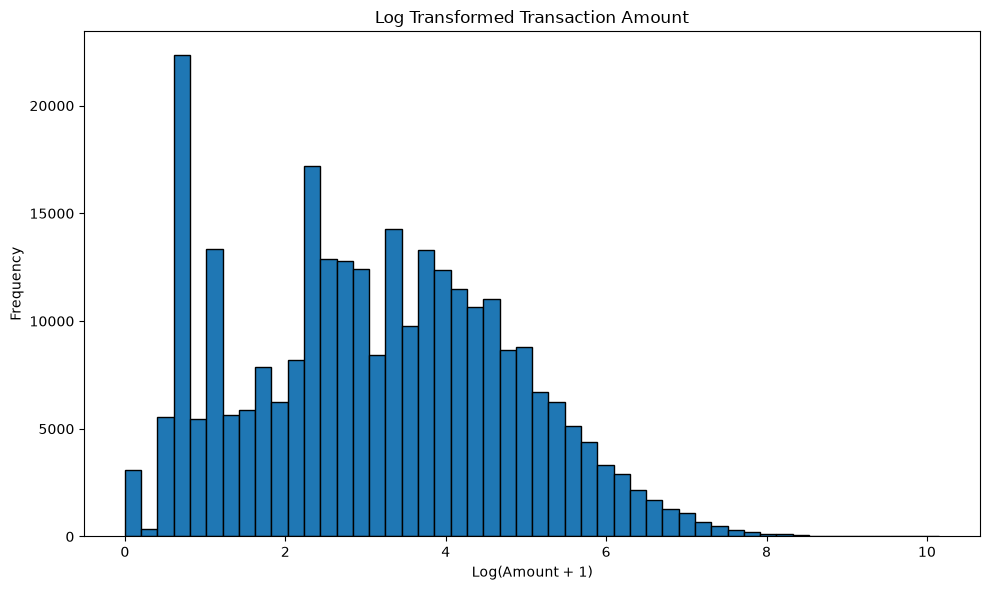

In [13]:

plt.figure(figsize=(10,6))

plt.hist(
    np.log1p(df['Amount']),
    bins=50,
    edgecolor='black'
)

plt.title('Log Transformed Transaction Amount')
plt.xlabel('Log(Amount + 1)')
plt.ylabel('Frequency')

plt.tight_layout()

plt.savefig(
    r"D:\Fraud Detection\reports\figures\log_transform_plot.png",
    dpi=300,
    bbox_inches = 'tight'
)

plt.show()

## Transaction Time Analysis

### Objective

Analyze the distribution of the Time feature to understand transaction occurrence over the recorded period and determine whether this feature may provide useful information for fraud detection.

The analysis will also help assess whether feature engineering may improve the usefulness of the Time variable.

### Business Questions

1. How are transactions distributed over time?
2. Does transaction activity remain consistent throughout the recorded period?
3. Are there periods with unusually high or low transaction volumes?
4. Is the Time feature directly useful for business interpretation?
5. Should Time be transformed into more meaningful features during preprocessing?

### Why is this analysis important?

Time is one of the only original features available in the dataset.

Although it does not represent actual clock time, analyzing its distribution helps us understand transaction patterns and determine whether additional feature engineering may improve model performance.

In [14]:
df['Time'].value_counts()

Time
163152.0    36
64947.0     26
68780.0     25
3767.0      21
3770.0      20
            ..
172784.0     1
172785.0     1
172786.0     1
172787.0     1
172792.0     1
Name: count, Length: 124592, dtype: int64

In [15]:
df['Time'].describe()

count    284807.000000
mean      94813.859575
std       47488.145955
min           0.000000
25%       54201.500000
50%       84692.000000
75%      139320.500000
max      172792.000000
Name: Time, dtype: float64

In [16]:
max_time = df["Time"].max()

days = max_time / (60 * 60 * 24)

In [17]:
print(max_time)

172792.0


In [18]:
print(days)

1.9999074074074075


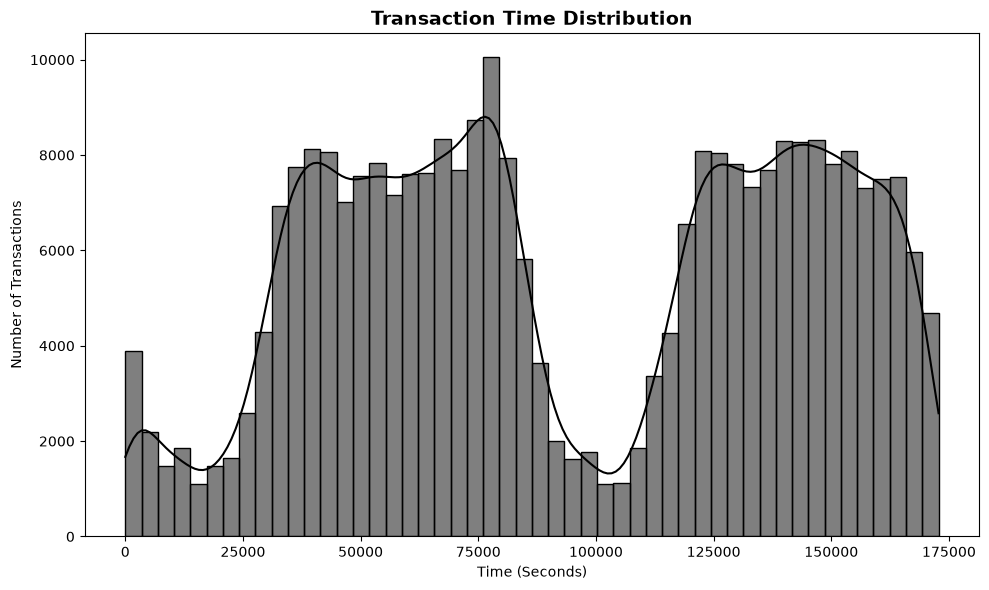

In [19]:
# Create figure
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x='Time',
    bins=50,
    kde=True,
    color='black'
)

# Customize plot
plt.title('Transaction Time Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Time (Seconds)')
plt.ylabel('Number of Transactions')

plt.tight_layout()

# Save figure
plt.savefig(
    "../reports/figures/time_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

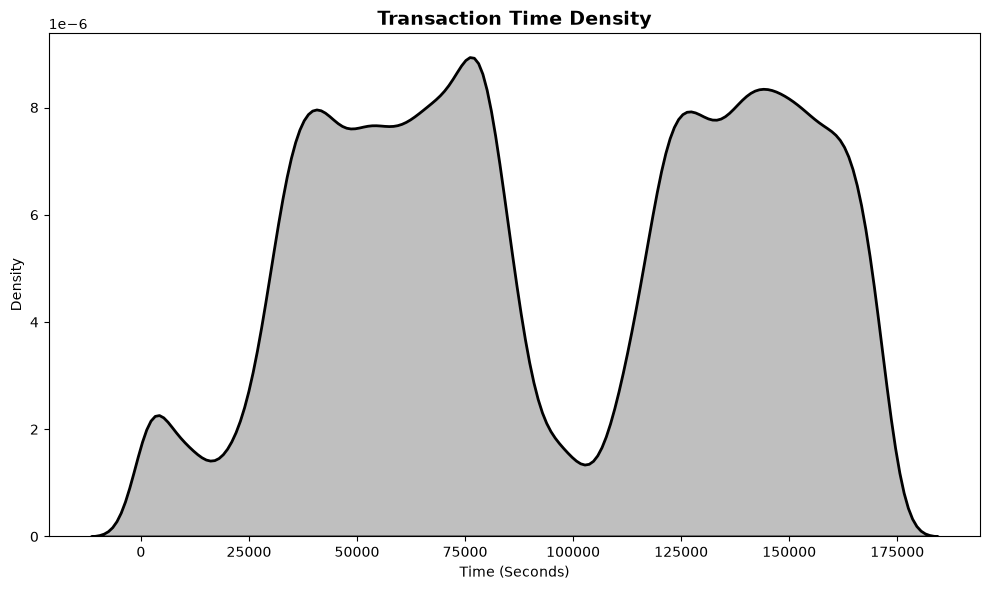

In [20]:
# Create figure
plt.figure(figsize=(10, 6))

# KDE plot
sns.kdeplot(
    data=df,
    x='Time',
    fill=True,
    linewidth=2,
    color='black'
)

# Customize plot
plt.title("Transaction Time Density", fontsize=14, fontweight='bold')
plt.xlabel("Time (Seconds)")
plt.ylabel("Density")

plt.tight_layout()

# Save figure
plt.savefig(
    "../reports/figures/time_kde.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

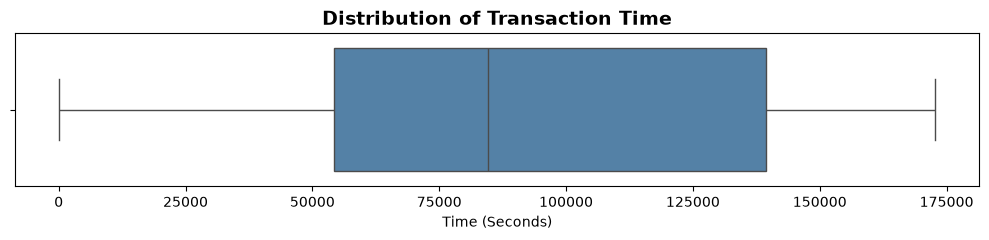

In [21]:
# Create figure
plt.figure(figsize=(10, 2.5))

# Boxplot
sns.boxplot(
    x=df['Time'],
    color='steelblue'
)

# Customize plot
plt.title('Distribution of Transaction Time', fontsize=14, fontweight='bold')
plt.xlabel('Time (Seconds)')

plt.tight_layout()

# Save figure
plt.savefig(
    "../reports/figures/time_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The Time feature represents elapsed seconds rather than actual timestamps. As a result, it cannot be directly interpreted by business stakeholders. Feature engineering would be required to convert it into meaningful temporal variables.



## 5. Bivariate Analysis

##  Fraud vs Transaction Amount

### Objective

Analyze whether transaction amount differs between legitimate and fraudulent transactions.

This analysis aims to identify whether transaction amount can help distinguish fraudulent transactions and provide business insights into fraud behavior.

### Business Questions

1. Do fraudulent transactions generally involve smaller or larger amounts?
2. Is there a noticeable difference in transaction amount between legitimate and fraudulent transactions?
3. Can transaction amount alone help identify fraudulent transactions?
4. Are there extreme fraudulent transaction amounts?
5. Is transaction amount likely to be an important feature for fraud detection?

### Why is this analysis important?

Transaction amount is one of the few features that has clear business meaning.

Comparing transaction amounts across fraud and legitimate classes helps determine whether fraudsters exhibit different spending behavior and whether transaction amount contributes meaningful information for fraud detection.

In [22]:
# Separate legitimate and fraudulent transactions
legitimate = df[df['Class'] == 0]
fraud = df[df['Class'] == 1]

In [23]:
print("Legitimate Transactions")
print(legitimate['Amount'].describe())

print("\n" + "="*50 + "\n")

print("Fraudulent Transactions")
print(fraud['Amount'].describe())

Legitimate Transactions
count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64


Fraudulent Transactions
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64


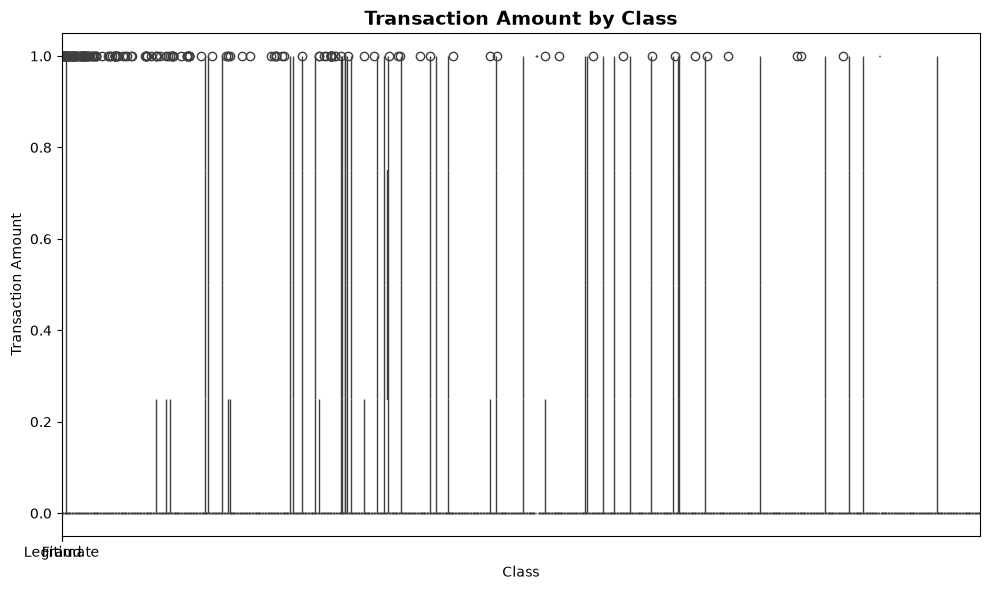

In [24]:
# Transaction Amount vs Class Boxplot

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x= 'Amount',
    y= 'Class'
)

# Improve labels
plt.title("Transaction Amount by Class", fontsize=14, fontweight='bold')
plt.xlabel("Class")
plt.ylabel("Transaction Amount")

# Rename x-axis labels
plt.xticks([0, 1], ["Legitimate", "Fraud"])

# Save figure
plt.tight_layout()


plt.savefig(
    "../reports/figures/fraud_vs_amount_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

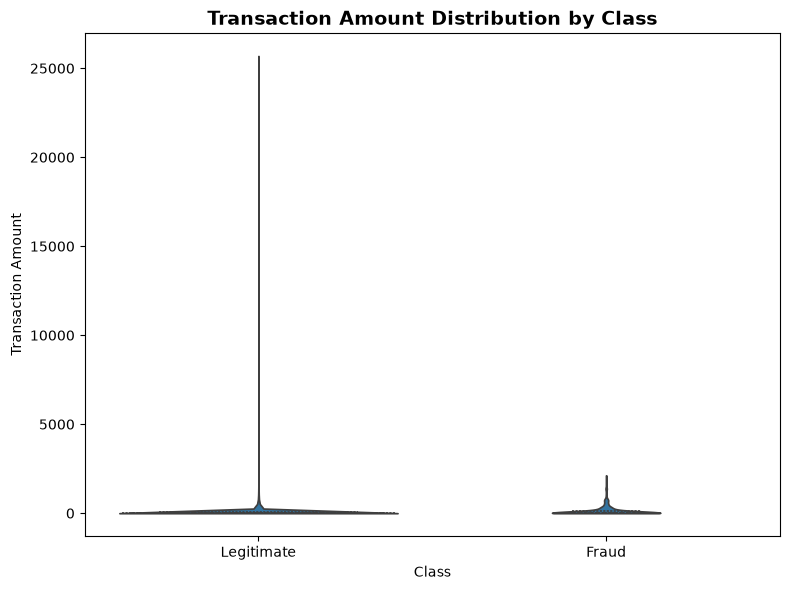

In [25]:
plt.figure(figsize=(8, 6))

sns.violinplot(
    data=df,
    x='Class',
    y='Amount',
    inner='quartile',      # Show quartiles inside the violin
    cut=0                  # Don't extend density beyond the data
)

# Customize plot
plt.title('Transaction Amount Distribution by Class', fontsize=14, fontweight='bold')
plt.xlabel('Class')
plt.ylabel('Transaction Amount')
plt.xticks([0, 1], ['Legitimate', 'Fraud'])

plt.tight_layout()

# Save figure
plt.savefig(
    "../reports/figures/fraud_vs_amount_violin.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

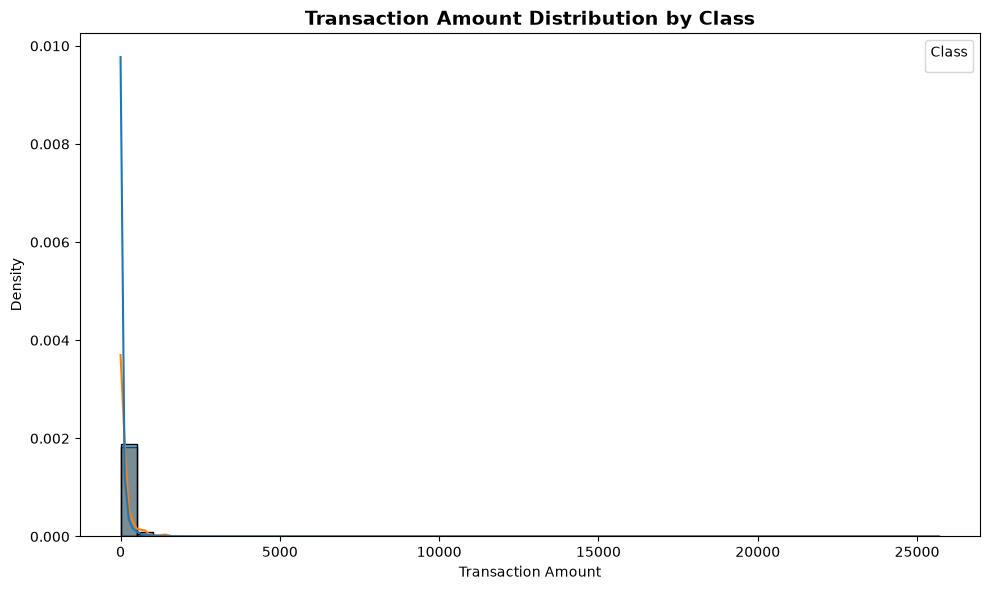

In [26]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x='Amount',
    hue='Class',
    bins=50,
    stat='density',          # Better for comparing imbalanced classes
    common_norm=False,       # Normalize each class separately
    kde=True,
    alpha=0.6
)

plt.title("Transaction Amount Distribution by Class", fontsize=14, fontweight='bold')
plt.xlabel("Transaction Amount")
plt.ylabel("Density")

# Rename legend labels
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['Legitimate', 'Fraud'], title='Class')

plt.tight_layout()

# Save figure
plt.savefig(
    "../reports/figures/fraud_amount_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Fraud vs Transaction Time

### Objective

Analyze whether fraudulent transactions exhibit different temporal patterns compared to legitimate transactions using the Time feature.

The objective is to determine whether transaction time provides useful information for fraud detection while understanding the limitations of the available time representation.

### Business Questions

1. Do fraudulent transactions occur uniformly throughout the observation period?
2. Is there any noticeable difference in transaction timing between fraud and legitimate transactions?
3. Does the Time feature alone help distinguish fraudulent transactions?
4. Can the bank directly use this Time feature for business decisions?
5. Should Time be transformed into more meaningful temporal features?

### Why is this analysis important?

Time is one of the few original features available in the dataset.

Although it represents elapsed seconds rather than actual timestamps, comparing transaction timing across fraud and legitimate classes may reveal temporal patterns that could improve fraud detection models.

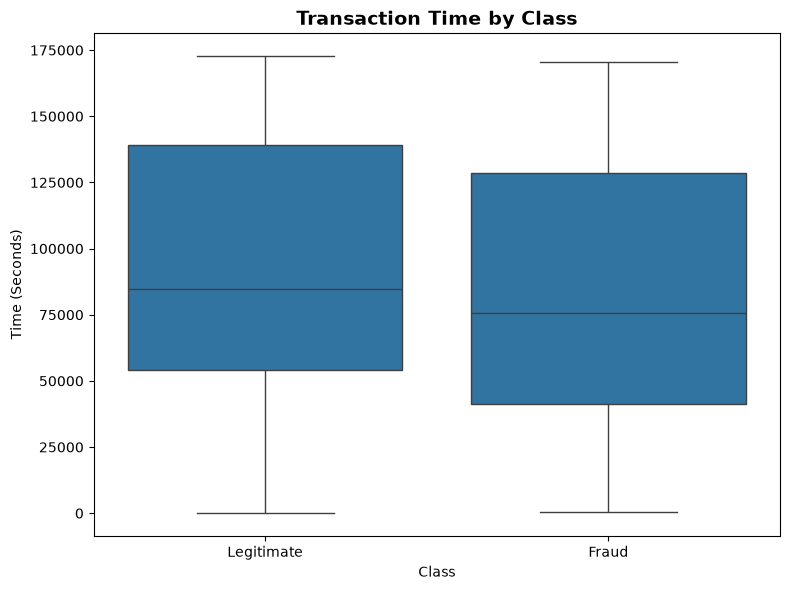

In [27]:
# Create figure
plt.figure(figsize=(8, 6))

# Boxplot
sns.boxplot(
    data=df,
    x='Class',
    y='Time'
)

# Customize plot
plt.title("Transaction Time by Class", fontsize=14, fontweight='bold')
plt.xlabel("Class")
plt.ylabel("Time (Seconds)")
plt.xticks([0, 1], ["Legitimate", "Fraud"])

plt.tight_layout()

# Save figure
plt.savefig(
    "../reports/figures/fraud_vs_time_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [28]:
# Separate summary statistics for each class

summary_stats = (
    df.groupby("Class")["Time"]
      .agg(
          Count="count",
          Mean="mean",
          Median="median",
          Std_Dev="std",
          Min="min",
          Max="max"
      )
      .round(2)
)

# Rename index for readability
summary_stats.index = ["Legitimate", "Fraud"]

summary_stats

,Count,Mean,Median,Std_Dev,Min,Max
Legitimate,284315,94838.20,84711.0,47484.02,0.0,172792.0
Fraud,492,80746.81,75568.5,47835.37,406.0,170348.0


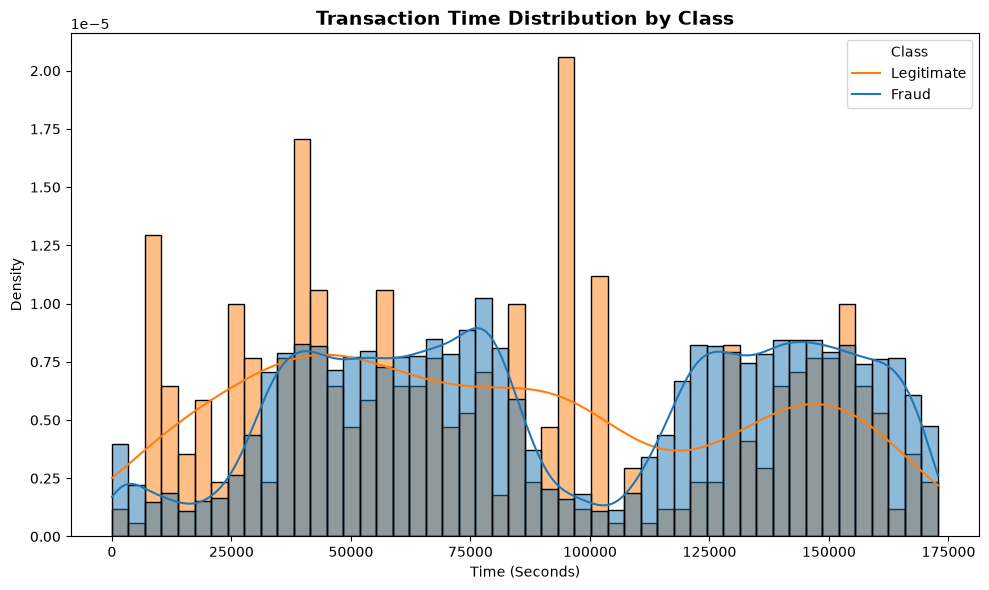

In [29]:

# Create figure
plt.figure(figsize=(10, 6))

# Overlay histogram
sns.histplot(
    data=df,
    x="Time",
    hue="Class",
    bins=50,
    stat="density",
    common_norm=False,
    kde=True,
    alpha=0.5
)

# Customize plot
plt.title("Transaction Time Distribution by Class", fontsize=14, fontweight="bold")
plt.xlabel("Time (Seconds)")
plt.ylabel("Density")

# Rename legend
plt.legend(
    title="Class",
    labels=["Legitimate", "Fraud"]
)

plt.tight_layout()

# Save figure
plt.savefig(
    "../reports/figures/fraud_time_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

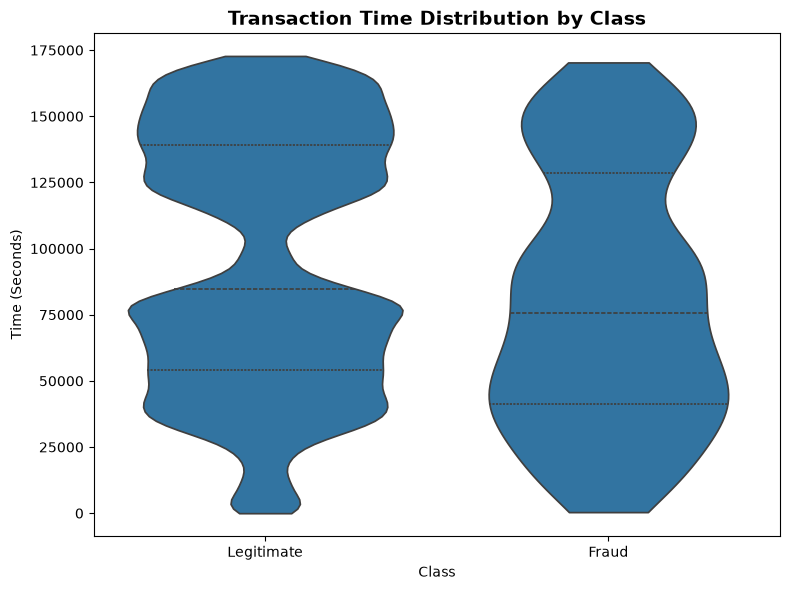

In [30]:

# Create figure
plt.figure(figsize=(8, 6))

# Violin plot
sns.violinplot(
    data=df,
    x='Class',
    y='Time',
    inner='quartile',
    cut=0
)

# Customize plot
plt.title("Transaction Time Distribution by Class", fontsize=14, fontweight='bold')
plt.xlabel("Class")
plt.ylabel("Time (Seconds)")
plt.xticks([0, 1], ["Legitimate", "Fraud"])

plt.tight_layout()

# Save figure
plt.savefig(
    "../reports/figures/fraud_vs_time_violin.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

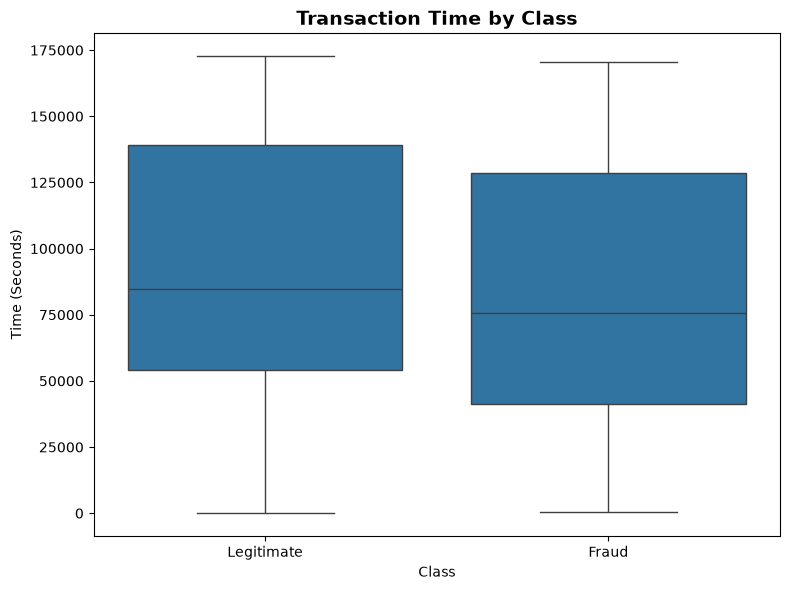

In [31]:

# Create figure
plt.figure(figsize=(8, 6))

# Boxplot
sns.boxplot(
    data=df,
    x='Class',
    y='Time'
)

# Customize plot
plt.title("Transaction Time by Class", fontsize=14, fontweight='bold')
plt.xlabel("Class")
plt.ylabel("Time (Seconds)")
plt.xticks([0, 1], ["Legitimate", "Fraud"])

plt.tight_layout()

# Save figure
plt.savefig(
    "../reports/figures/fraud_vs_time_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



## 6. Correlation Analysis

### Objective

The objective of this section is to understand the linear relationship between the dataset features and identify which variables are most strongly associated with fraudulent transactions.

Since most predictor variables are PCA-transformed and anonymized, correlation analysis helps identify potentially important features for model development without requiring business interpretation of the original variables.

### Business Questions

1. Which features are most strongly associated with fraudulent transactions?

2. Which features have positive correlations with fraud?

3. Which features have negative correlations with fraud?

4. Are there features that appear unrelated to fraud?

5. Can correlation analysis help prioritize important variables for model development?

### Why is this analysis important?

Understanding feature relationships helps identify variables that may contribute significantly to fraud detection.

Although correlation does not imply causation, features with stronger correlations to the target variable often provide useful predictive information and deserve closer examination during model development.

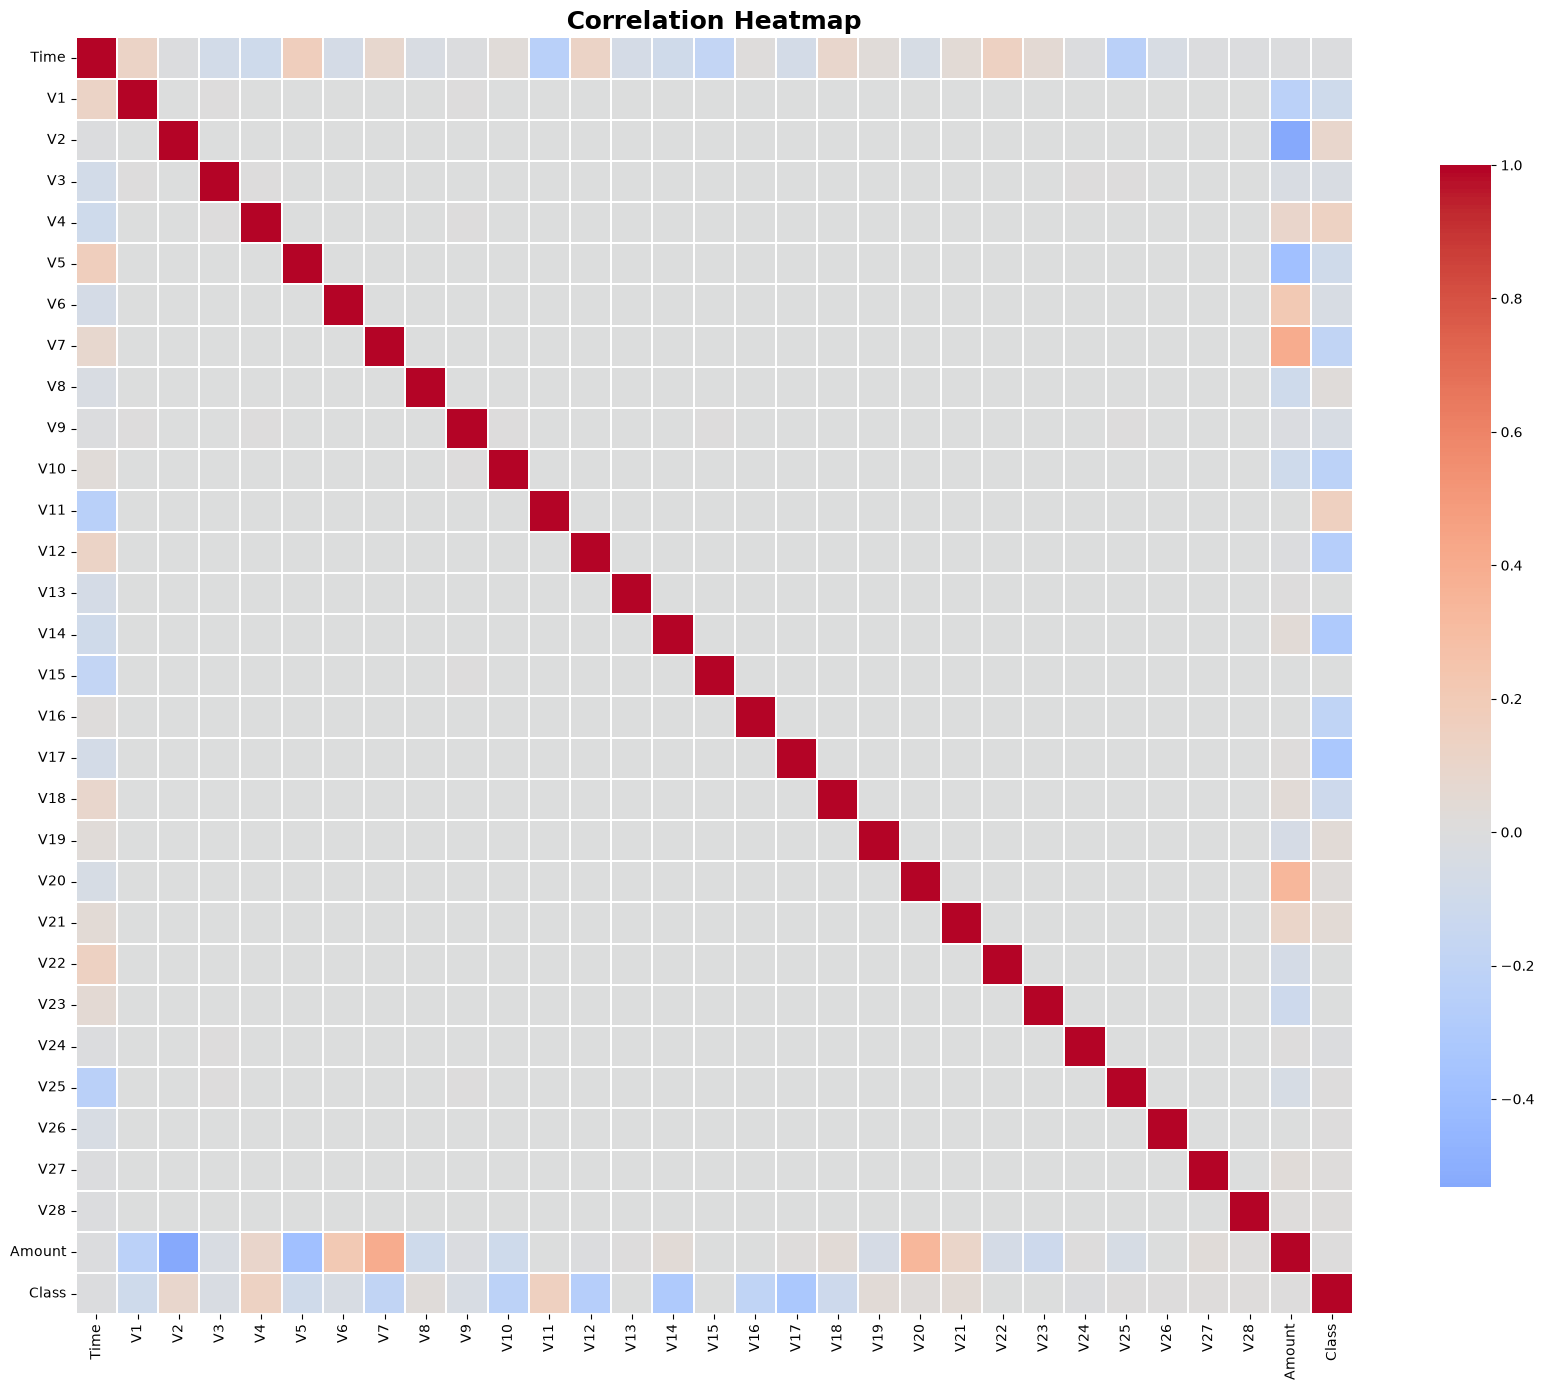

In [32]:
# Compute correlation atrix
corr_matrix = df.corr(numeric_only=True)

# Create figure
plt.figure(figsize=(18, 14))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.3,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Heatmap", fontsize=18, fontweight="bold")

plt.tight_layout()

plt.savefig(
    "../reports/figures/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [34]:

# Calculate correlation of all features with the target
class_corr = (
    df.corr(numeric_only=True)["Class"]
      .drop("Class")
      .sort_values()
)

# Convert to DataFrame
corr_table = (
    class_corr
    .reset_index()
    .rename(columns={
        "index": "Feature",
        "Class": "Correlation with Class"
    })
)

# Display table
corr_table

,Feature,Correlation with Class
0,V17,-0.326481
1,V14,-0.302544
2,V12,-0.260594
3,V10,-0.216522
4,V16,-0.196539
5,V7,-0.187260
6,V18,-0.111485
7,V1,-0.101348
8,V5,-0.094976
9,V6,-0.043644


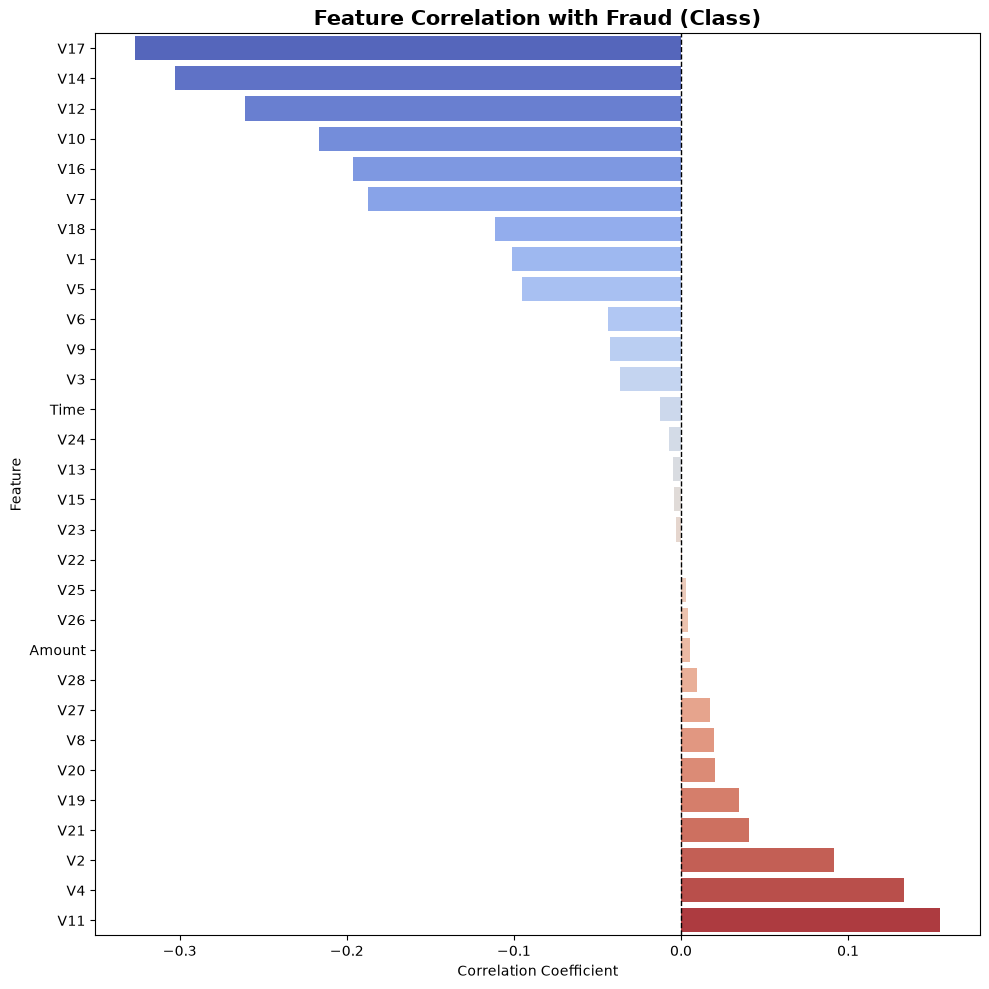

In [35]:
# Horizontal Bar Chart

plot_data = class_corr.sort_values()


plt.figure(figsize=(10,10))

sns.barplot(
    x=plot_data.values,
    y=plot_data.index,
    palette="coolwarm"
)

plt.axvline(0, color="black", linestyle="--", linewidth=1)

plt.title(
    "Feature Correlation with Fraud (Class)",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Correlation Coefficient")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    "../reports/figures/class_correlation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [36]:
# Top 10 Positive Features

positive_features = (
    df.corr(numeric_only=True)["Class"]
    .drop("Class")
    .sort_values(ascending=False)
    .head(10)
)

positive_table = (
    positive_features
    .reset_index()
    .rename(
        columns={
            "index": "Features",
            "Class": "Correlation with Class"
        })
    )

positive_table

,Features,Correlation with Class
0,V11,0.154876
1,V4,0.133448
2,V2,0.091289
3,V21,0.040413
4,V19,0.034783
5,V20,0.020090
6,V8,0.019875
7,V27,0.017580
8,V28,0.009536
9,Amount,0.005632


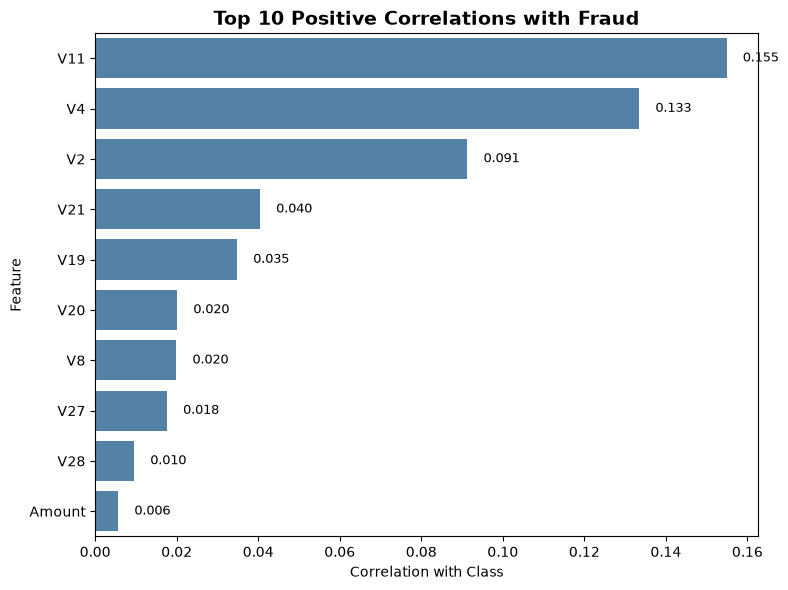

In [38]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=positive_table,
    x="Correlation with Class",
    y="Features",
    color="steelblue"
)

for i, value in enumerate(positive_table["Correlation with Class"]):
    plt.text(
        value + 0.003,
        i,
        f"{value: .3f}",
        va="center",
        fontsize=9
    )

plt.title(
    "Top 10 Positive Correlations with Fraud",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Correlation with Class")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    "../reports/figures/top_positive_features.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [39]:
# Get the 10 most negative correlations with the target
negative_features = (
    df.corr(numeric_only=True)["Class"]
      .drop("Class")
      .sort_values(ascending=True)
      .head(10)
)

# Convert to DataFrame
negative_table = (
    negative_features
    .reset_index()
    .rename(columns={
        "index": "Feature",
        "Class": "Correlation with Class"
    })
)

negative_table

,Feature,Correlation with Class
0,V17,-0.326481
1,V14,-0.302544
2,V12,-0.260594
3,V10,-0.216522
4,V16,-0.196539
5,V7,-0.187260
6,V18,-0.111485
7,V1,-0.101348
8,V5,-0.094976
9,V6,-0.043644


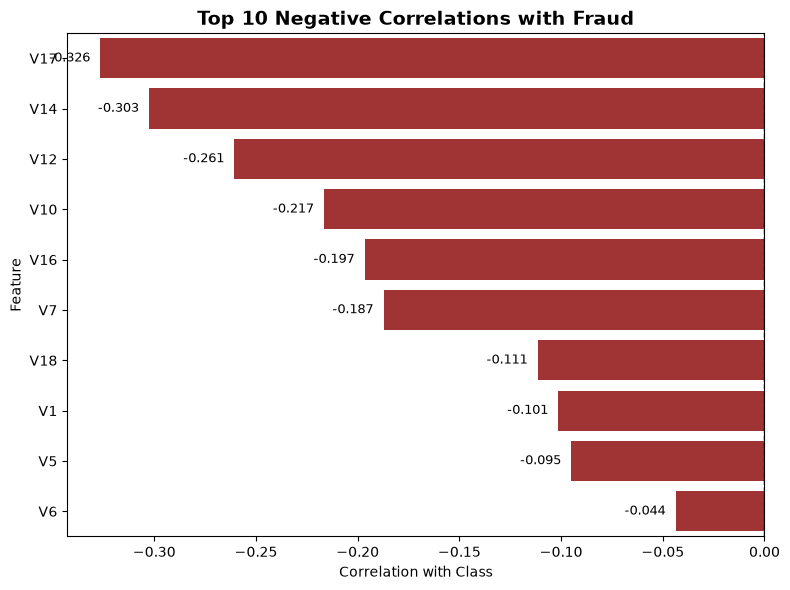

In [41]:
# Create figure
plt.figure(figsize=(8, 6))

# Horizontal bar chart
sns.barplot(
    data=negative_table,
    x="Correlation with Class",
    y="Feature",
    color="firebrick"
)

# Add value labels
for i, value in enumerate(negative_table["Correlation with Class"]):
    plt.text(
        value - 0.005,
        i,
        f"{value:.3f}",
        va="center",
        ha="right",
        fontsize=9
    )

# Reference line
plt.axvline(0, color="black", linestyle="--", linewidth=1)

# Customize plot
plt.title(
    "Top 10 Negative Correlations with Fraud",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Correlation with Class")
plt.ylabel("Feature")

plt.tight_layout()

# Save figure
plt.savefig(
    "../reports/figures/top_negative_features.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



## 7. Outlier Analysis

### Objective

The objective of this section is to identify extreme observations in the dataset, understand whether they represent data quality issues or genuine business behavior, and determine how they should be handled during preprocessing.

Special attention is given to the Amount feature and the most highly correlated PCA features, as these may significantly influence machine learning models.

### Business Questions

1. Which features contain extreme values?
2. Are these outliers likely to represent genuine transactions or data errors?
3. Should outliers be removed before model training?
4. How might outliers affect different machine learning algorithms?
5. Can outliers themselves be useful indicators of fraud?

### Why is this analysis important?

Outliers can significantly influence statistical summaries and certain machine learning algorithms.

However, in fraud detection, unusual transactions may represent the very events the model is intended to identify. Therefore, it is essential to distinguish between erroneous data and legitimate but rare behavior before deciding whether to remove or retain outliers.

<function matplotlib.pyplot.show(close=None, block=None)>

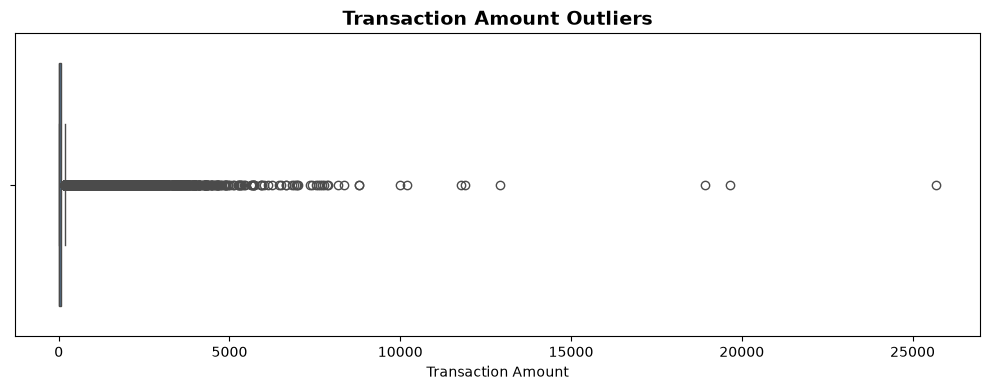

In [42]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    x=df["Amount"],
    color="steelblue"
)

plt.title(
    "Transaction Amount Outliers",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Transaction Amount")

plt.tight_layout()

plt.savefig(
    "../reports/figures/outlier_amount.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show

In [43]:
# Calculate Quartiles
Q1 = df["Amount"].quantile(0.25)
Q3 = df["Amount"].quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

# Calculate Bounds
lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

# Identify Outliers
outliers = df[
    (df["Amount"] < lower_bound) |
    (df["Amount"] > upper_bound)
]

# Display Results
print(f"Q1           : {Q1:.2f}")
print(f"Q3           : {Q3:.2f}")
print(f"IQR          : {IQR:.2f}")
print(f"Lower Bound  : {lower_bound:.2f}")
print(f"Upper Bound  : {upper_bound:.2f}")
print(f"Outliers     : {len(outliers):,}")

Q1           : 5.60
Q3           : 77.16
IQR          : 71.56
Lower Bound  : -101.75
Upper Bound  : 184.51
Outliers     : 31,904


In [44]:
iqr_summary = {
    "Metric": [
        "Q1",
        "Q3",
        "IQR",
        "Lower Bound",
        "Upper Bound",
        "Number of Outliers"
    ],
    "Value": [
        round(Q1, 2),
        round(Q3, 2),
        round(IQR, 2),
        round(lower_bound, 2),
        round(upper_bound, 2),
        len(outliers)
    ]
}

iqr_summary = pd.DataFrame(iqr_summary)

iqr_summary

,Metric,Value
0,Q1,5.60
1,Q3,77.16
2,IQR,71.56
3,Lower Bound,-101.75
4,Upper Bound,184.51
5,Number of Outliers,31904.00


In [45]:
outlier_percentage = (len(outliers) / len(df)) * 100

print(f"Outlier Percentage: {outlier_percentage:.2f}%")

Outlier Percentage: 11.20%


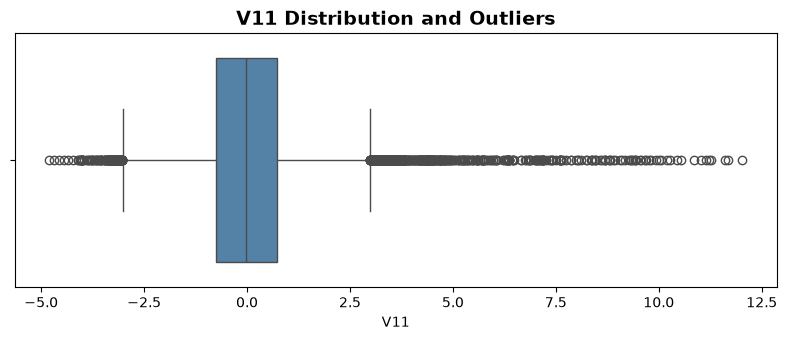

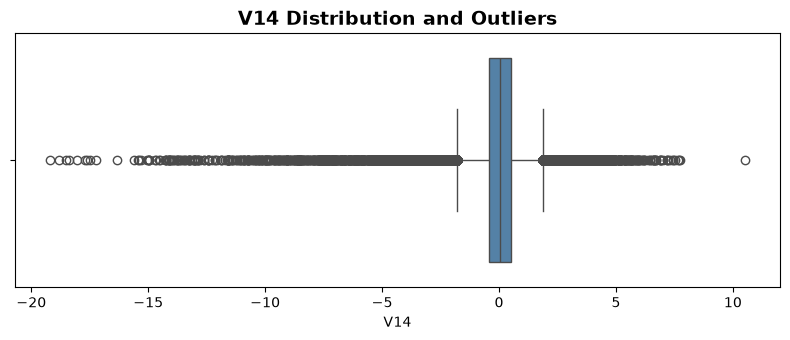

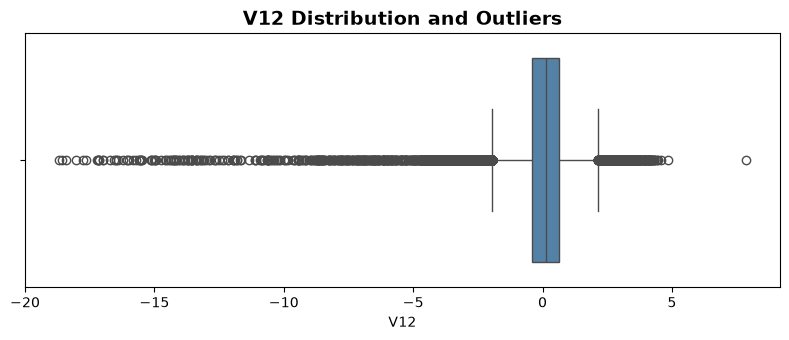

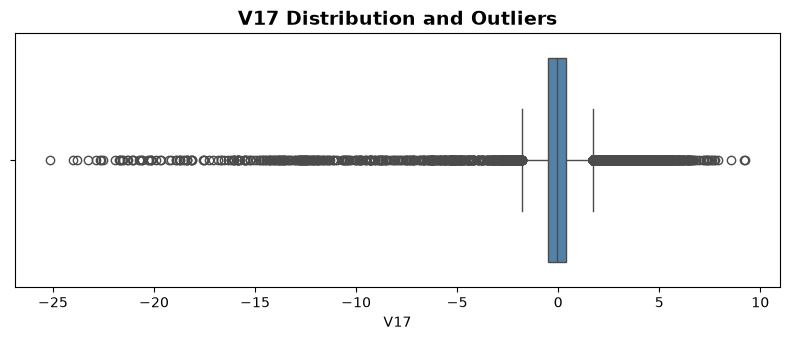

In [46]:

# Features to visualize
features = ["V11", "V14", "V12", "V17"]

for feature in features:

    plt.figure(figsize=(8, 3.5))

    sns.boxplot(
        x=df[feature],
        color="steelblue"
    )

    plt.title(
        f"{feature} Distribution and Outliers",
        fontsize=14,
        fontweight="bold"
    )

    plt.xlabel(feature)

    plt.tight_layout()

    plt.savefig(
        f"../reports/figures/{feature}_boxplot.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

## Outlier Comparison Summary

| Feature | Outliers Present | Remove? | Reason |
|---------|:----------------:|:-------:|--------|
| **Amount** | Yes | **No** | High-value transactions may represent legitimate purchases or fraudulent activity. Removing them could eliminate important fraud patterns. |
| **V11** | Yes | **No** | One of the strongest positively correlated features with fraud. Extreme values likely contain useful predictive information. |
| **V14** | Yes | **No** | Strong negative correlation with fraud. Outliers are expected in PCA-transformed features and help distinguish fraudulent transactions. |
| **V12** | Yes | **No** | Highly informative PCA feature. Removing extreme observations could reduce model performance. |
| **V17** | Yes | **No** | Among the most predictive features for fraud detection. Outliers are likely meaningful rather than erroneous. |

### Conclusion

| Analysis | Finding |
|----------|---------|
| **Amount Outliers** | Significant right-skew with many high-value outliers. |
| **PCA Feature Outliers** | Outliers present across key PCA features and likely contain fraud-related information. |
| **Recommendation** | Retain all outliers; apply scaling where appropriate rather than removing observations. |



## 8. Business Insights

| Finding | Business Insight | Business Impact |
|----------|------------------|-----------------|
| **1. Severe Class Imbalance** | Fraudulent transactions represent only **0.17%** of all transactions. | A model optimized only for accuracy could miss most fraud cases while still appearing highly accurate. Evaluation should focus on Recall, Precision, F1-score, and PR-AUC rather than Accuracy. |
| **2. Majority of Transactions are Low Value** | Most customer transactions are of relatively small amounts, indicating normal day-to-day spending behavior. | Fraud detection should not rely solely on transaction amount because both legitimate and fraudulent transactions frequently involve small values. |
| **3. High-Value Transactions Exist** | A small number of transactions involve very large amounts and appear as statistical outliers. | High-value transactions require additional verification but should not be automatically classified as fraudulent because they may represent genuine customer purchases. |
| **4. Fraud and Legitimate Transactions Overlap in Amount** | Fraudulent transactions do not occur exclusively at high or low transaction amounts. | Transaction amount alone cannot distinguish fraudulent from legitimate activity. Multiple behavioral signals must be evaluated together. |
| **5. Transaction Time Covers Approximately Two Days** | The dataset represents about two days of transaction activity. | Short observation periods limit long-term behavioral analysis. Additional historical data would improve fraud detection in production systems. |
| **6. Raw Time Feature Has Limited Business Value** | Time is stored as elapsed seconds rather than actual timestamps. | The feature is not directly interpretable by business users and should be transformed into meaningful temporal features (e.g., hour of day, transaction frequency) if actual timestamps are available. |
| **7. Fraud Occurs Throughout the Observation Period** | Fraudulent transactions are distributed across the recorded time period rather than being confined to a single interval. | The bank cannot create simple time-based rules to detect fraud. Time should be combined with other variables. |
| **8. PCA Features Show Strong Statistical Signals** | Features such as **V11, V14, V12, and V17** exhibit stronger correlations with fraud than most other variables. | These features are valuable for predictive modeling, although they cannot be translated into direct business actions because they are anonymized. |
| **9. Most Features Have Weak Individual Correlation** | Most variables individually have weak linear relationships with the target. | Fraud detection depends on combining multiple features rather than relying on any single indicator. This supports the use of machine learning over simple rule-based systems. |
| **10. Significant Outliers are Present** | Amount and several important PCA features contain many extreme values. | These outliers likely represent genuine business behavior or fraudulent activity rather than data errors and should generally be retained for modeling. |
| **11. No Missing Values** | The dataset is complete. | Minimal preprocessing is required for missing data, allowing focus on feature engineering and model development. |
| **12. Duplicate Transactions Exist** | 1,081 duplicate records were identified. | These records should be investigated before removal because duplicate transactions may represent legitimate repeated purchases or duplicated observations. |

EDA demonstrates that fraudulent transactions cannot be reliably identified using individual variables such as transaction amount or elapsed time. Instead, fraud detection requires combining multiple transaction characteristics to recognize complex behavioral patterns. While anonymized PCA features provide strong predictive signals, additional business-interpretable features would improve explainability and support more actionable fraud prevention strategies.



## 9. Summary

| Analysis | Key Finding | Business Impact | Modeling Decision |
|----------|-------------|-----------------|-------------------|
| Class Distribution | Highly imbalanced | Accuracy is misleading | Use Precision, Recall, F1, PR-AUC |
| Transaction Amount | Highly right-skewed | Large variation in spending | Scale if required |
| Fraud vs Amount | Heavy overlap | Amount alone is insufficient | Combine with other features |
| Transaction Time | Covers ~2 days | Elapsed seconds lack business meaning | Engineer temporal features |
| Fraud vs Time | Significant overlap | Time alone is weak | Create behavioral timing features |
| Correlation Analysis | Few PCA features strongly correlated | Useful for prediction but not interpretation | Retain features for modeling |



## 10. Next Steps